# Problem Statement

Tujuan utama dari proyek ini adalah untuk mentransformasi data transaksi historis menjadi wawasan strategis guna mengoptimalkan performa bisnis. Secara mendetail, objektif proyek ini adalah:
* **Meningkatkan Akurasi Prediksi:** Membangun model peramalan (forecasting) yang mampu memprediksi volume penjualan di masa depan dengan tingkat error minimal.
* **Optimasi Manajemen Inventori:** Memberikan dasar estimasi kebutuhan stok barang untuk mencegah terjadinya *overstock* (penumpukan barang) maupun *stock-out* (kehabisan barang).
* **Efisiensi Strategi Pemasaran:** Mengidentifikasi periode puncak (peak seasons) dan segmen produk paling potensial untuk pengalokasian anggaran pemasaran yang lebih efektif.

# Business Objective

Perusahaan menghadapi tantangan dalam mengelola ketidakpastian permintaan pasar yang dinamis. Masalah utama yang diidentifikasi meliputi:
* **Ketidakpastian Fluktuasi Penjualan:** Tanpa adanya prediksi yang terukur, pengambilan keputusan stok hanya didasarkan pada intuisi, yang sering kali menyebabkan inefisiensi biaya operasional.
* **Identifikasi Pola Musiman:** Sulitnya menentukan kapan permintaan akan melonjak (misal: efek hari raya atau akhir tahun) dan kapan akan menurun jika hanya melihat data mentah tanpa analisis deret waktu (*time series analysis*).
* **Gap Analisis Wilayah dan Produk:** Belum adanya pemetaan yang jelas mengenai kontribusi tiap wilayah (*Region*) dan kategori produk terhadap stabilitas pendapatan jangka panjang.


# Target Variable

* **`Sales` (Target Utama):** Merupakan variabel kontinu yang merepresentasikan total nilai moneter dari setiap transaksi. Dalam analisis *time series*, variabel ini akan di-agregasi berdasarkan satuan waktu (misal: Bulanan) untuk melihat tren pertumbuhan.


**Fitur Pendukung (Prediktor):**
* **`Order Date`:** Digunakan untuk mengekstrak komponen waktu (Tahun, Bulan, Hari, Kuartal).
* **`Category` & `Sub-Category`:** Variabel kategori untuk melihat perbedaan pola permintaan antar lini produk.
* **`Region`:** Variabel geografis untuk memahami distribusi spasial dari performa penjualan.

# Varibles

| Nama Kolom | Deskripsi |
| :--- | :--- |
| **Row ID** | Nomor urut unik untuk setiap baris dalam dataset. |
| **Order ID** | Kode identifikasi unik untuk setiap transaksi/pesanan. |
| **Order Date** | Tanggal saat pesanan dilakukan oleh pelanggan. |
| **Ship Date** | Tanggal saat pesanan dikirimkan ke pelanggan. |
| **Ship Mode** | Metode pengiriman yang digunakan (e.g., Standard Class, First Class). |
| **Customer ID** | Kode identifikasi unik untuk setiap pelanggan. |
| **Customer Name** | Nama lengkap pelanggan yang melakukan transaksi. |
| **Segment** | Segmen pasar pelanggan (Consumer, Corporate, atau Home Office). |
| **Country** | Negara tempat transaksi dilakukan. |
| **City** | Kota tujuan pengiriman pesanan. |
| **State** | Negara bagian tujuan pengiriman. |
| **Postal Code** | Kode pos lokasi tujuan pengiriman. |
| **Region** | Wilayah geografis pengiriman (Central, East, South, West). |
| **Product ID** | Kode identifikasi unik untuk setiap produk. |
| **Category** | Kategori utama produk (Furniture, Office Supplies, Technology). |
| **Sub-Category** | Kategori turunan yang lebih spesifik dari setiap produk. |
| **Product Name** | Nama lengkap atau deskripsi produk yang terjual. |
| **Sales** | Nilai total pendapatan dari transaksi tersebut (Target Variable). |

---

# Data For Prediction

In [167]:
import kagglehub
import pandas as pd
import os

In [168]:
# path = kagglehub.dataset_download("rohitsahoo/sales-forecasting")

In [169]:
# print("Lokasi file:", path)
# print("Isi folder:", os.listdir(path))

In [170]:
path = r'C:\Users\Lenovo\.cache\kagglehub\datasets\rohitsahoo\sales-forecasting\versions\2'
df = pd.read_csv(f"{path}/train.csv")

In [171]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


# Data Understanding

In [172]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [173]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [174]:
# Ubah Order and Ship date menjadi format datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')

## Distribution Customer

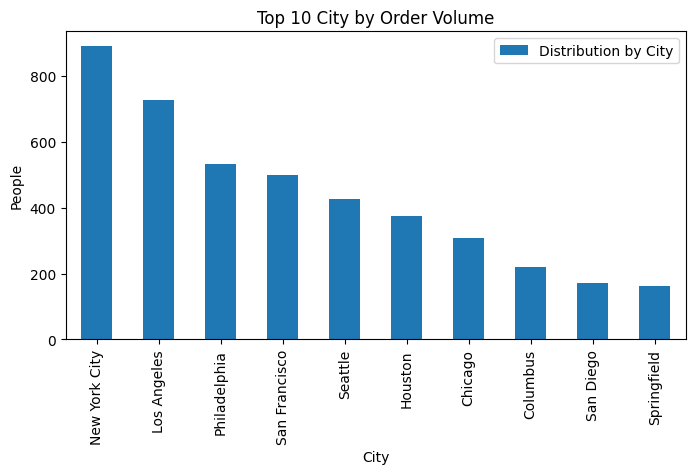

In [175]:
# Distribution by City
dis_city = df.groupby('City')['Order ID'].count().sort_values(ascending=False).reset_index(name='Distribution by City')

ax = dis_city.head(10).plot(x='City', 
                   y='Distribution by City', 
                   kind='bar', 
                   xlabel='City', 
                   ylabel='People', 
                   figsize=(8,4), 
                   title='Top 10 City by Order Volume')

## Tampilkan Spesific Number
# ax.bar_label(ax.containers[0], padding=3)
# plt.show()

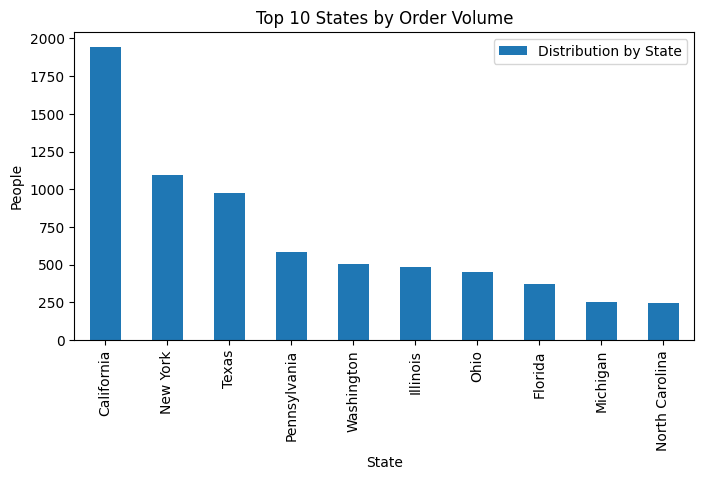

In [176]:
# Distribution by State
dis_state = df.groupby('State')['Order ID'].count().sort_values(ascending=False).reset_index(name='Distribution by State')

ax = dis_state.head(10).plot(x='State', 
                   y='Distribution by State', 
                   kind='bar', 
                   xlabel='State', 
                   ylabel='People', 
                   figsize=(8,4), 
                   title='Top 10 States by Order Volume')

# dis_state.head()

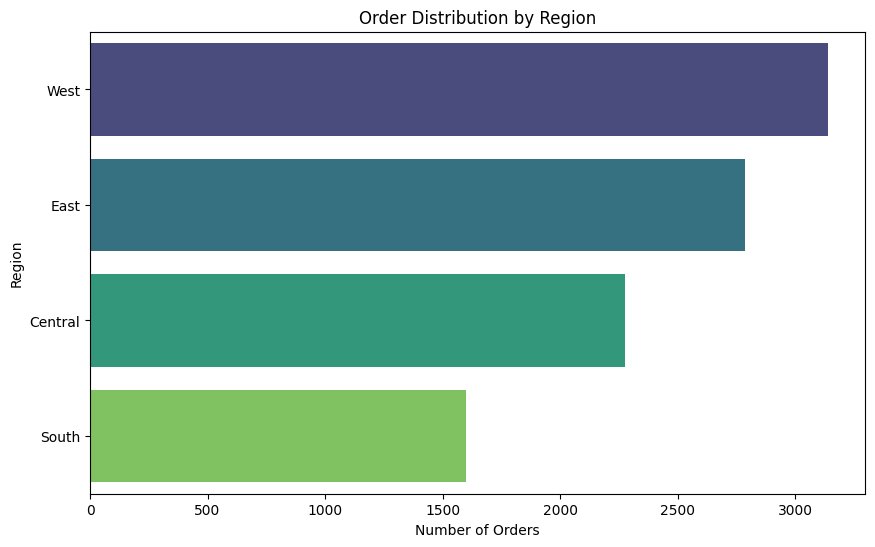

In [177]:
dis_reg = df.groupby('Region')['Order ID'].count().sort_values(ascending=False).reset_index(name='Distribution by Region')

plt.figure(figsize=(10, 6))
sns.barplot(dis_reg,
            x='Distribution by Region',
            y='Region',
            palette='viridis',
            )
plt.title('Order Distribution by Region')
plt.xlabel('Number of Orders')
plt.ylabel('Region')
plt.show()

## Distribution by Category

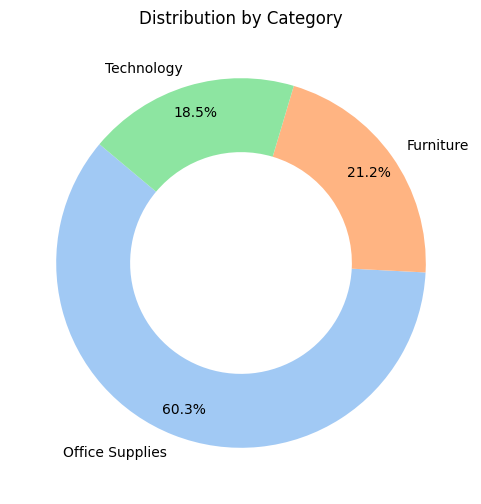

In [178]:
sales_category = df.groupby('Category')['Order ID'].count().sort_values(ascending=False).reset_index(name='Distribution by Category')

colors = sns.color_palette('pastel')[0:3]

plt.figure(figsize=(6,6))
plt.pie(sales_category['Distribution by Category'],
        labels=sales_category['Category'],
        autopct='%1.1f%%',
        startangle=140,
        colors=colors,
        pctdistance=0.85,
        wedgeprops=dict(width=0.4))

plt.title('Distribution by Category')
plt.show()

## Day with 0 Sales

In [179]:
range_ideal = pd.date_range(start='2015-01-01', end='2018-12-31', freq='D')

tanggal_dataset = df['Order Date'].dt.normalize().unique()

hari_hilang = range_ideal.difference(tanggal_dataset)

print(f"Total Hari yang Hilang : {len(hari_hilang)}")
# print(hari_hilang)

Total Hari yang Hilang : 231


# Data Preparation

## Baseline

In [180]:
# Set Order Date sebagai index
df_temp = df.set_index('Order Date')

# Resample Group per Minggu
df_weekly = df_temp['Sales'].resample('W').sum().reset_index()

df_weekly.columns = ['Order Date', 'Total Sales']

df_weekly['month'] = df_weekly['Order Date'].dt.month
df_weekly['week_of_year'] = df_weekly['Order Date'].dt.isocalendar().week
# lag Features
df_weekly['sales_last_week'] = df_weekly['Total Sales'].shift(1)

df_weekly['sales_last_week'] = df_weekly['sales_last_week'].fillna(0)
df_weekly.head()

,Order Date,Total Sales,month,week_of_year,sales_last_week
0,2015-01-04,304.508,1,1,0.000
1,2015-01-11,4619.108,1,2,304.508
2,2015-01-18,4130.533,1,3,4619.108
3,2015-01-25,3092.544,1,4,4130.533
4,2015-02-01,2527.914,2,5,3092.544


In [181]:
df_weekly['rolling_mean_4w'] = df_weekly['Total Sales'].shift(1).rolling(window=4).mean()
df_weekly['rolling_mean_4w'] = df_weekly['rolling_mean_4w'].fillna(0)
df_weekly.head(5)

,Order Date,Total Sales,month,week_of_year,sales_last_week,rolling_mean_4w
0,2015-01-04,304.508,1,1,0.000,0.00000
1,2015-01-11,4619.108,1,2,304.508,0.00000
2,2015-01-18,4130.533,1,3,4619.108,0.00000
3,2015-01-25,3092.544,1,4,4130.533,0.00000
4,2015-02-01,2527.914,2,5,3092.544,3036.67325


### Correlation Check

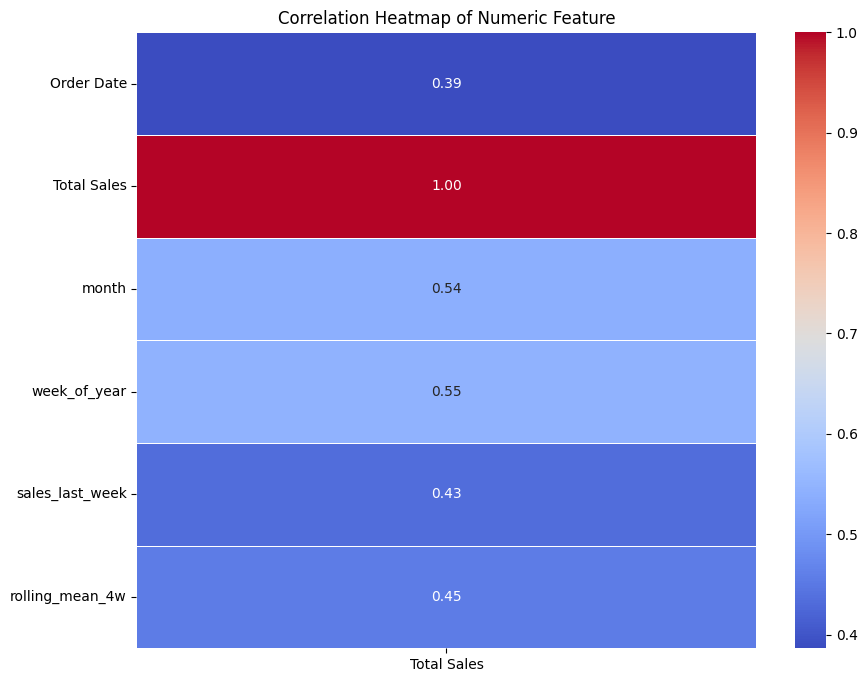

In [182]:
corr = df_weekly.corr()[['Total Sales']] 

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr, 
    annot=True, 
    cmap='coolwarm', 
    fmt='.2f', 
    linewidths=0.5
)
plt.title('Correlation Heatmap of Numeric Feature')
plt.show()

### Split Category

In [183]:
def prepare_sales_data(df, category_name):
    df_cat = df[df['Category'] == category_name].copy()

    df_resampled = df_cat.set_index('Order Date')['Sales'].resample('MS').sum().reset_index()
    df_resampled.columns = ['Order Date', 'Total Sales']

    return df_resampled

df_office = prepare_sales_data(df, 'Office Supplies')
df_furniture = prepare_sales_data(df, 'Furniture')
df_tech = prepare_sales_data(df, 'Technology')

In [184]:
train_office = df_office[df_office['Order Date'] < '2018-01-01']
test_office = df_office[df_office['Order Date'] >= '2018-01-01']

train_furniture = df_furniture[df_furniture['Order Date'] < '2018-01-01']
test_furniture = df_furniture[df_furniture['Order Date'] >= '2018-01-01']

train_tech = df_tech[df_tech['Order Date'] < '2018-01-01']
test_tech = df_tech[df_tech['Order Date'] >= '2018-01-01']

# Modeling & Evaluate

## Arima

In [185]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, r2_score
import warnings

warnings.filterwarnings("ignore")

### Office Supplies 

In [186]:
train_off_ts = train_office.set_index('Order Date')['Total Sales']
test_off_ts = test_office.set_index('Order Date')['Total Sales']

model_off = ARIMA(train_off_ts, order=(1, 1, 1))
model_fit_off = model_off.fit()

forecast_off = model_fit_off.forecast(steps=12)
print(f"Office Supplies MAE: {mean_absolute_error(test_off_ts, forecast_off):.2f}")
print(f"Office Supplies R2: {r2_score(test_off_ts, forecast_off):.2f}")

Office Supplies MAE: 8976.29
Office Supplies R2: -0.54


### Furniture

In [187]:
train_furn_ts = train_furniture.set_index('Order Date')['Total Sales']
test_furn_ts = test_furniture.set_index('Order Date')['Total Sales']

model_furn = ARIMA(train_furn_ts, order=(1, 1, 1))
model_fit_furn = model_furn.fit()

forecast_furn = model_fit_furn.forecast(steps=12)

print(f"Furniture MAE: {mean_absolute_error(test_furn_ts, forecast_furn):.2f}")
print(f"Furniture R2: {r2_score(test_furn_ts, forecast_furn):.2f}")


Furniture MAE: 10652.68
Furniture R2: -0.51


### Technology

In [188]:
train_tech_ts = train_tech.set_index('Order Date')['Total Sales']
test_tech_ts = test_tech.set_index('Order Date')['Total Sales']

model_tech = ARIMA(train_tech_ts, order=(1, 1, 1))
model_fit_tech = model_tech.fit()

forecast_tech = model_fit_tech.forecast(steps=12)

print(f"Technology MAE: {mean_absolute_error(test_tech_ts, forecast_tech):.2f}")
print(f"Technology R2: {r2_score(test_tech_ts, forecast_tech):.2f}")


Technology MAE: 8728.16
Technology R2: -0.07


## Prophet

In [189]:
from prophet import Prophet

21:57:37 - cmdstanpy - INFO - Chain [1] start processing
21:57:39 - cmdstanpy - INFO - Chain [1] done processing


--- Prophet Results: Office Supplies ---
MAE: 5401.30
R2 Score: 0.16



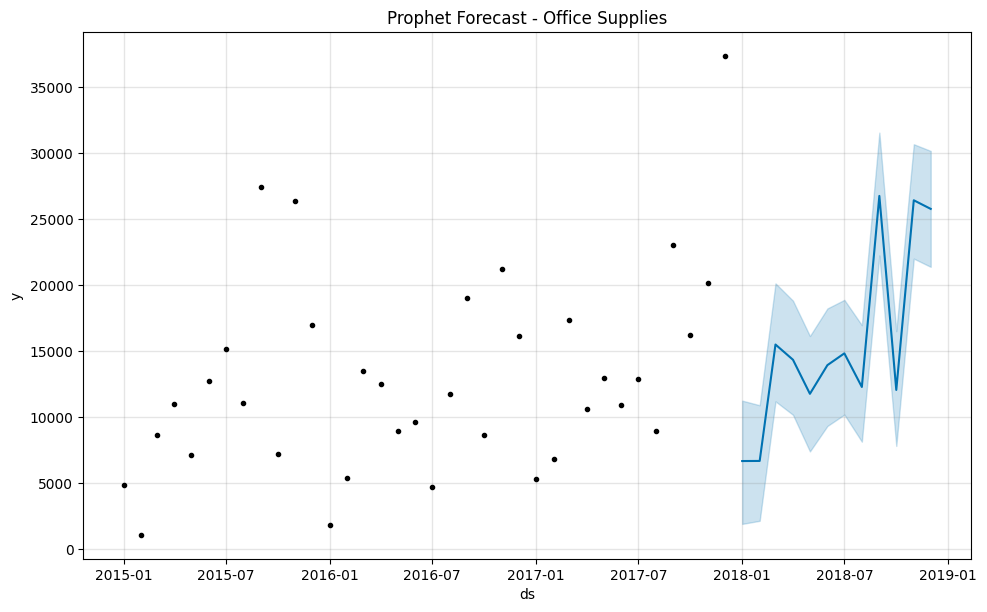

21:57:42 - cmdstanpy - INFO - Chain [1] start processing
21:57:43 - cmdstanpy - INFO - Chain [1] done processing


--- Prophet Results: Furniture ---
MAE: 3744.66
R2 Score: 0.80



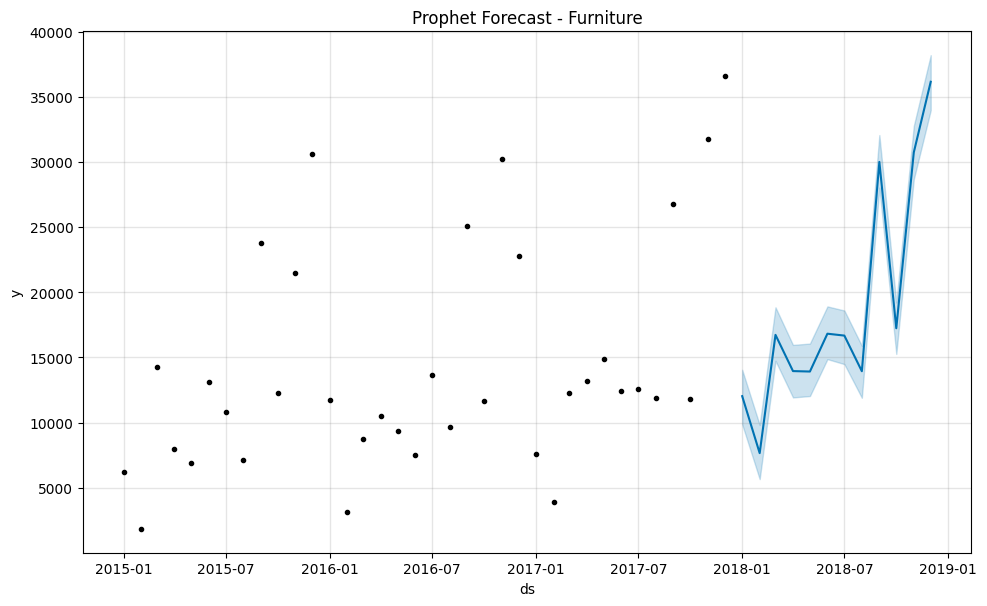

21:57:44 - cmdstanpy - INFO - Chain [1] start processing
21:57:44 - cmdstanpy - INFO - Chain [1] done processing


--- Prophet Results: Technology ---
MAE: 6607.43
R2 Score: 0.52



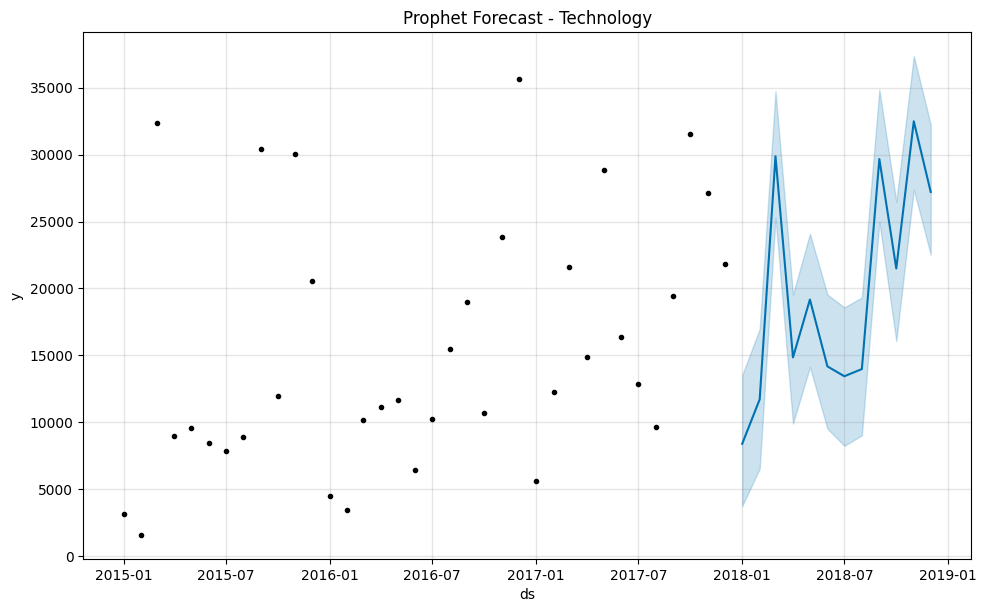

In [190]:
categories_p = [
    ('Office Supplies', df_office.rename(columns={'Order Date': 'ds', 'Total Sales': 'y'})),
    ('Furniture', df_furniture.rename(columns={'Order Date': 'ds', 'Total Sales': 'y'})),
    ('Technology', df_tech.rename(columns={'Order Date': 'ds', 'Total Sales': 'y'}))
]

for name, data in categories_p:

    train = data[data['ds'] < '2018-01-01']
    test = data[data['ds'] >= '2018-01-01']
    
    model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    model.fit(train)
    
    future = test[['ds']] # Ambil tanggal di tahun 2018
    forecast = model.predict(future)
    
    y_true = test['y'].values
    y_pred = forecast['yhat'].values
    
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"--- Prophet Results: {name} ---")
    print(f"MAE: {mae:.2f}")
    print(f"R2 Score: {r2:.2f}\n")
    
    # 7. Visualisasi (Bawaan Prophet keren banget, Bro)
    fig = model.plot(forecast)
    plt.title(f'Prophet Forecast - {name}')
    plt.show()


# Improvement Model

In [191]:
import itertools

def evaluate_arima_model(train_data, test_data, p_range, d_range, q_range):
    best_score, best_cfg = float("inf"), None

    pdq_combinations = list(itertools.product(p_range, d_range, q_range))
    
    for pdq in pdq_combinations:
        try:
            model = ARIMA(train_data, order=pdq)
            model_fit = model.fit()
            predictions = model_fit.forecast(steps=len(test_data))
            mae = mean_absolute_error(test_data, predictions)
            
            if mae < best_score:
                best_score, best_cfg = mae, pdq
        except:
            continue
    return best_cfg, best_score

# Range yang kita coba (0 sampai 2)
p = d = q = range(0, 3)

In [192]:
# Tuning Technology (Yang paling potensial)
best_order_tech, _ = evaluate_arima_model(train_tech_ts, test_tech_ts, p, d, q)
print(f"Best ARIMA Order for Technology: {best_order_tech}")

# Tuning Furniture
best_order_furn, _ = evaluate_arima_model(train_furn_ts, test_furn_ts, p, d, q)
print(f"Best ARIMA Order for Furniture: {best_order_furn}")

# Tuning Office Supplies
best_order_off, _ = evaluate_arima_model(train_off_ts, test_off_ts, p, d, q)
print(f"Best ARIMA Order for Office Supplies: {best_order_off}")


Best ARIMA Order for Technology: (2, 1, 2)
Best ARIMA Order for Furniture: (2, 0, 2)
Best ARIMA Order for Office Supplies: (1, 0, 1)


## Update Model Arima

### Office Supplies

In [193]:
model_off_final = ARIMA(train_off_ts, order=(1, 0, 1))
fit_off_final = model_off_final.fit()
forecast_off_final = fit_off_final.forecast(steps=12)

print(f"--- Office Supplies Tuned ---")
print(f"New MAE: {mean_absolute_error(test_off_ts, forecast_off_final):.2f}")
print(f"New R2 : {r2_score(test_off_ts, forecast_off_final):.2f}")

--- Office Supplies Tuned ---
New MAE: 8142.43
New R2 : -0.66


### Furniture 

In [194]:
model_furn_final = ARIMA(train_furn_ts, order=(2, 0, 2))
fit_furn_final = model_furn_final.fit()
forecast_furn_final = fit_furn_final.forecast(steps=12)

print(f"--- Furniture Tuned ---")
print(f"New MAE: {mean_absolute_error(test_furn_ts, forecast_furn_final):.2f}")
print(f"New R2 : {r2_score(test_furn_ts, forecast_furn_final):.2f}")

--- Furniture Tuned ---
New MAE: 6910.05
New R2 : 0.19


### Technology

In [195]:
model_tech_final = ARIMA(train_tech_ts, order=(2, 1, 2))
fit_tech_final = model_tech_final.fit()
forecast_tech_final = fit_tech_final.forecast(steps=12)

print(f"--- Technology Tuned ---")
print(f"New MAE: {mean_absolute_error(test_tech_ts, forecast_tech_final):.2f}")
print(f"New R2 : {r2_score(test_tech_ts, forecast_tech_final):.2f}")

--- Technology Tuned ---
New MAE: 7987.52
New R2 : 0.12
